In [1]:
# from src.MPOptoClass import *
from src.utils.gen_utils import *
from src.utils.filters import *
from src.experiment import *
from src.wiener_filter import *
from src.modeller import *
from src.MPRecordClass import *
from src.ReachingClass import *
from src.analysis import *
import scipy
import copy
import time
import mat73 
import pynapple as nap
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps
import random
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from itertools import permutations, compress, product
from tqdm import tqdm




%load_ext autoreload 
%autoreload 2
%matplotlib widget

# load

In [2]:
output = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [3]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=4

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

session_name = output[sesh][0][2][1]
inact = output[sesh][0][2][2]

session_path = f'../data/co/co7/{session_name}'
session = MPOptoClass(session_path)

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    regs.append(run[2][0])
    h_list.append(c[0])
    l_ratio.append(c[1])
    #c_ratio.append(c[2])
   
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    
    l_r2.append(c[3])
    c_r2.append(c[4])
    
    h_sw_list.append(sw[0])
    lsw_ratio.append(sw[1])
    
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    #sw_ratio.append(sw[2])
    lsw_r2.append(sw[3])
    sw_r2.append(sw[4])

love


# top models

In [4]:
top_ratio, top_r2, idxs, _ = get_top_models(c_ratio, c_r2, num_bins=15)

[-4.76929869 -4.12646213 -3.48369538 -2.84123481 -1.56463752 -0.84501578
 -0.24279214  0.39716286  0.89820293  1.4815398   2.10663342  3.38695647
  4.0295812   4.67238539  5.31523048]


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


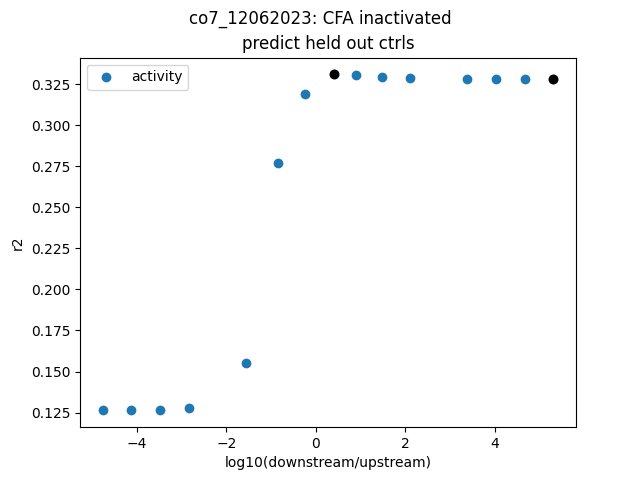

In [5]:
fig, ax = plt.subplots()
ax.scatter(top_ratio, top_r2, label='activity')
ax.scatter(top_ratio[7], top_r2[7], color='black')
ax.scatter(top_ratio[14], top_r2[14], color='black')
#ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out ctrls')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

# how do weights of these two models compare

In [6]:
top_h = np.array(h_list)[idxs]

In [7]:
h1 = top_h[7,:,:]
h2 = top_h[14,:,:]


In [8]:
pre=100
post=50
binsize=5
nlags=20
num_PCs=20



laser_bounds, ctrl_bounds = session.adjustLaserBounds(pre, post, only_climb=True)
(X, Y), PCs = session.generate_trainset(bounds=session.climbing_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_laser, Y_laser = session.generate_testset(PCs, laser_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)
X_ctrl, Y_ctrl = session.generate_testset(PCs, ctrl_bounds, binsize=binsize, nlags=nlags, num_PCs=num_PCs)

In [9]:
yhat1_ctrl = test_wiener_filter(X_ctrl, h1)
yhat2_ctrl = test_wiener_filter(X_ctrl, h2)

yhat1_laser = test_wiener_filter(X_laser, h1)
yhat2_laser = test_wiener_filter(X_laser, h2)
print(weighted_r2(Y_ctrl, yhat1_ctrl))
print(weighted_r2(Y_ctrl, yhat2_ctrl))


temp1, temp2 = session.relative_input(h1, X_ctrl, nlags, num_region1=num_PCs)
print(np.log10(temp1/temp2))
temp1, temp2 = session.relative_input(h2, X_ctrl, nlags, num_region1=num_PCs)
print(np.log10(temp1/temp2))

0.35510247349071905
0.3507664254528896
0.5960862191727152
5.328345811556847


In [10]:
varz = np.var(Y_laser, axis=0)
h1_col = collapse_h(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

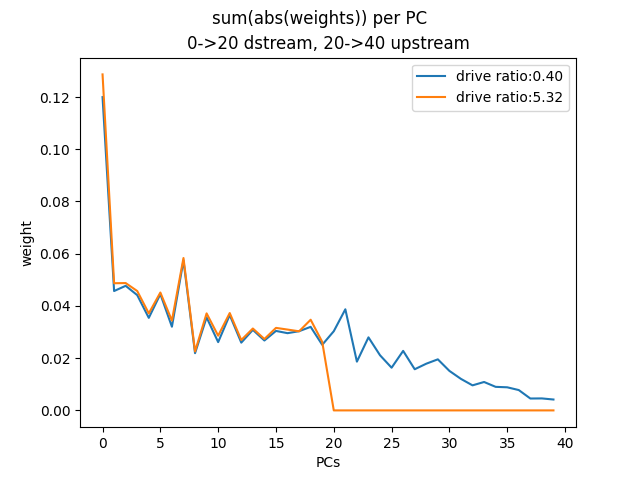

In [11]:
fig, ax = plt.subplots()
ax.plot(h1_col, label=f'drive ratio:{top_ratio[7]:.2f}')
ax.plot(h2_col, label=f'drive ratio:{top_ratio[14]:.2f}')
ax.legend()
fig.suptitle('sum(abs(weights)) per PC')
ax.set_title('0->20 dstream, 20->40 upstream')
ax.set_ylabel('weight')
ax.set_xlabel('PCs')

# any difference over lags?

In [12]:
varz = np.var(Y_laser, axis=0)
h1_col = collapse_h_lags(h1, nlags=nlags, var=varz, bias=True)
h2_col = collapse_h_lags(h2, nlags=nlags, var=varz, bias=True)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'lag')

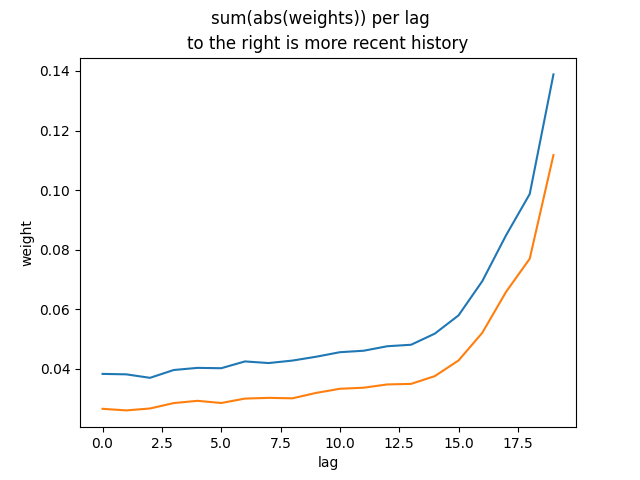

In [13]:
fig, ax = plt.subplots()
ax.plot(h1_col)
ax.plot(h2_col)
fig.suptitle('sum(abs(weights)) per lag')
ax.set_title('to the right is more recent history')
ax.set_ylabel('weight')
ax.set_xlabel('lag')

# residuals look quite similar, different weights but similar predictions

In [14]:
yhat1_ctrl = test_wiener_filter(X_ctrl, h1)
yhat2_ctrl = test_wiener_filter(X_ctrl, h2)
res1 = (Y_ctrl - yhat1_ctrl)**2
res2 = (Y_ctrl - yhat2_ctrl)**2

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'time (5ms bins)')

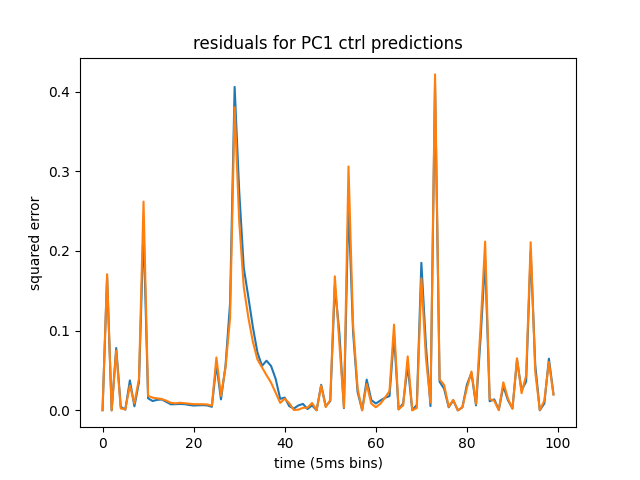

In [15]:
fig, ax = plt.subplots()

ax.plot(res1[500:600,0])
ax.plot(res2[500:600,0])
ax.set_title('residuals for PC1 ctrl predictions')
ax.set_ylabel('squared error')
ax.set_xlabel('time (5ms bins)')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


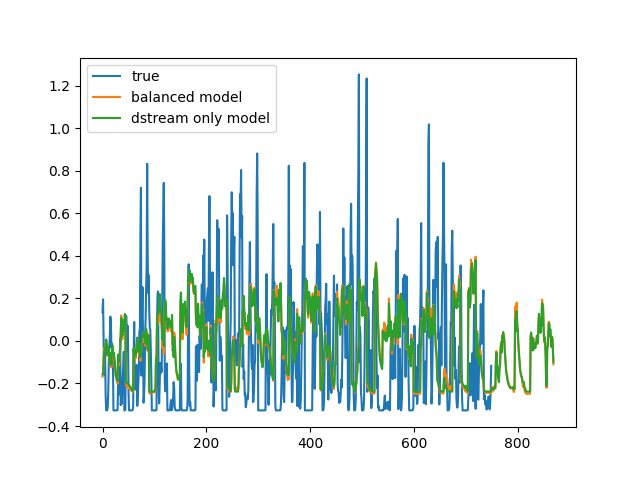

In [16]:
fig, ax = plt.subplots()
ax.plot(Y_laser[:,0], label='true')
ax.plot(yhat1_ctrl[:,0], label='balanced model')
ax.plot(yhat2_ctrl[:,0], label='dstream only model')
ax.legend()

# lets now look at all 8 similar models find a "null axis" along which the models can change while the predictions do not

## first lets collapse across lags for simpler models and concatenate them

In [ ]:
hs = top_h[7:,:,:]
h_concat = np.empty((8,40))
for idx, h in enumerate(hs):
    h = np.expand_dims(h, 1)
    h_col = collapse_h(h, nlags=20, bias=True)
    h_concat[idx,:]=h_col

In [61]:
h_concat.shape

(8, 40)

# run PCA to find linear combination of PCs that capture variance between models

In [64]:
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(h_concat)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0, 0.5, 'percent variance explained')

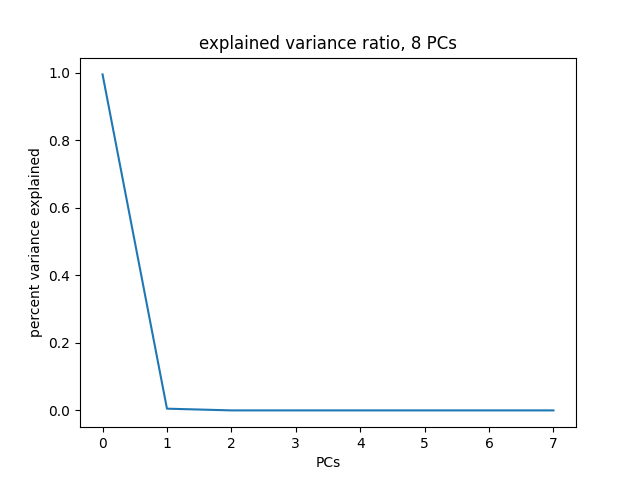

In [65]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_xlabel('PCs')
ax.set_ylabel('percent variance explained')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

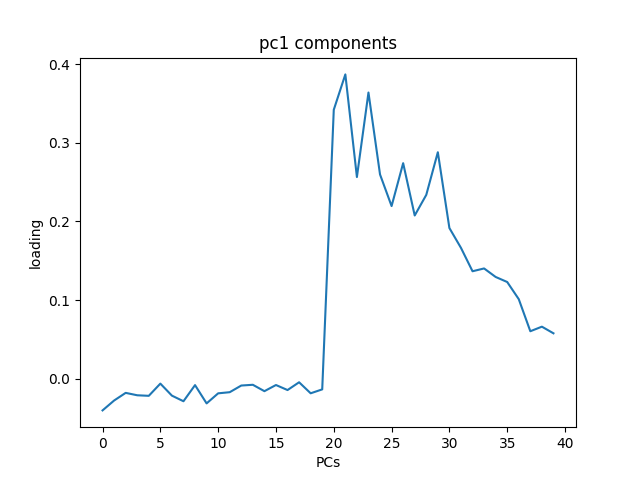

In [66]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.components_[0,:])
ax.set_title('pc1 components')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

# lets do in high dimensional space (without collapsing), although only predicting 1st PC of dstream region

# 8 models w/ 800 features (40 PCs * 20 lags)

In [17]:
hs = top_h[7:,1:,0]
#h_concat = np.reshape(hs, (8, 801))
h_PCAobj = PCA(n_components=8)
h_PCA = h_PCAobj.fit_transform(hs)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'PCs')

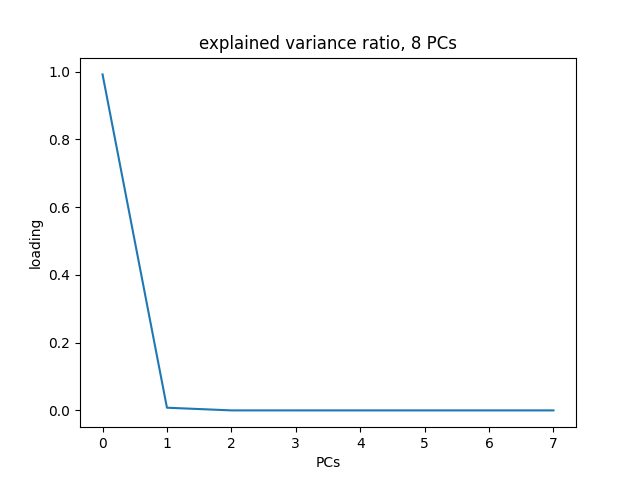

In [18]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.explained_variance_ratio_)
ax.set_title('explained variance ratio, 8 PCs')
ax.set_ylabel('loading')
ax.set_xlabel('PCs')

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


Text(0.5, 0, 'features (PCs and lags)')

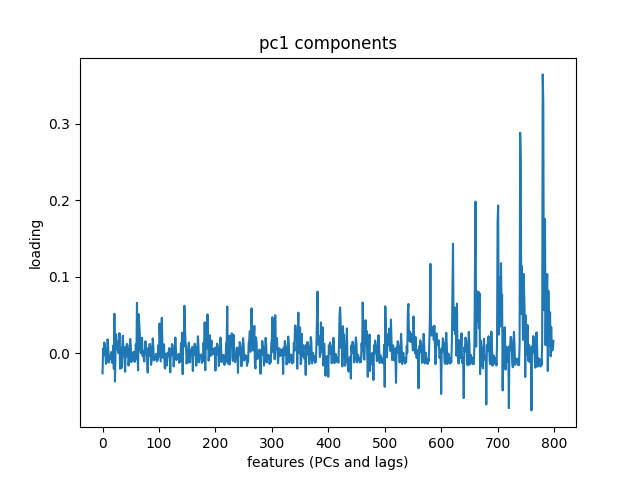

In [19]:
fig, ax = plt.subplots()
ax.plot(h_PCAobj.components_[0,:])
ax.set_title('pc1 components')
ax.set_ylabel('loading')
ax.set_xlabel('features (PCs and lags)')

In [20]:
h_null = np.expand_dims(h_PCAobj.components_[0,:].T, axis=1)

In [21]:
h_null.shape

(800, 1)

# if this PC captures a "null axis," lets project original ctrl activity on this axis, separated by regions.

In [47]:
h_mask1, h_mask2 = session.mask_h_region(h_null, nlags=20, num_region1=20, has_bias=False)
h_null1 = h_null[h_mask1,:]
h_null2 = h_null[h_mask2,:]

mask1, mask2 = session.mask_input_region(X_ctrl, nlags=20, num_region1=20)
X_ctrl1 = X_ctrl[:, mask1]
X_ctrl2 = X_ctrl[:, mask2]

h_mask1, h_mask2 = session.mask_h_region(h1, nlags=20, num_region1=20, has_bias=True)
h_ctrl1 = h1[h_mask1,0]
h_ctrl2 = h1[h_mask2,0]

In [23]:
h_ctrl1.shape

(400,)

In [24]:
null_proj1 = np.squeeze(X_ctrl1@h_null1)
null_proj2 = np.squeeze(X_ctrl2@h_null2)

ctrl_proj1 = np.squeeze(X_ctrl1@h_ctrl1)
ctrl_proj2 = np.squeeze(X_ctrl2@h_ctrl2)

PearsonRResult(statistic=0.5744496209848355, pvalue=1.552055017902364e-77)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


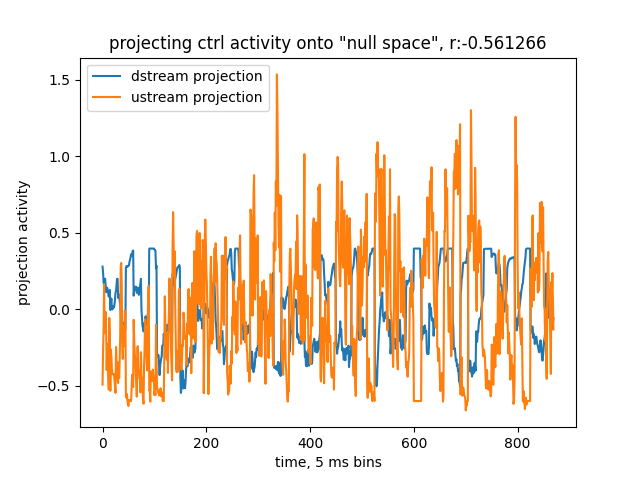

In [34]:
fig, ax = plt.subplots()
ax.plot(null_proj1, label='dstream projection')
ax.plot(null_proj2, label='ustream projection')
ax.legend()
ax.set_ylabel('projection activity')
ax.set_xlabel('time, 5 ms bins')
r = scipy.stats.pearsonr(null_proj1, null_proj2)
ax.set_title(f'projecting ctrl activity onto "null space", r:{r[0]:1f}')
print(scipy.stats.pearsonr(ctrl_proj1, ctrl_proj2))

In [50]:
h_null = h_PCAobj.components_.T
h_null1 = h_null[h_mask1,:]
h_null2 = h_null[h_mask2,:]

IndexError: boolean index did not match indexed array along dimension 0; dimension is 800 but corresponding boolean dimension is 801

In [45]:
X_all1 = X[:, mask1]
X_all2 = X[:, mask2]

null_proj1 = np.squeeze(X_all1@h_null1)
null_proj2 = np.squeeze(X_all2@h_null2)

In [43]:
h = train_wiener_filter(null_proj1, Y, c=(0,1))
yhat = test_wiener_filter(null_proj1, h)
print(weighted_r2(Y_ctrl, yhat))

h = train_wiener_filter(null_proj2, Y, c=(0,2))
yhat = test_wiener_filter(null_proj2, h)
print(weighted_r2(Y_ctrl, yhat))

best_c: 1.0
0.3453515963385814
best_c: 35.93813663804626
0.1755987199085658


In [84]:
mask1, mask2 = session.mask_input_region(X_laser, nlags=20, num_region1=20)
X_laser1 = X_laser[:, mask1]
X_laser2 = X_laser[:, mask2]

In [85]:
null_proj1 = np.squeeze(X_laser1@h_null1)
null_proj2 = np.squeeze(X_laser2@h_null2)

In [86]:
num_lasers = laser_bounds.shape[0]

In [87]:
X_laser.shape

(750, 800)

PearsonRResult(statistic=-0.5774374141924186, pvalue=6.599910825387765e-68)


/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


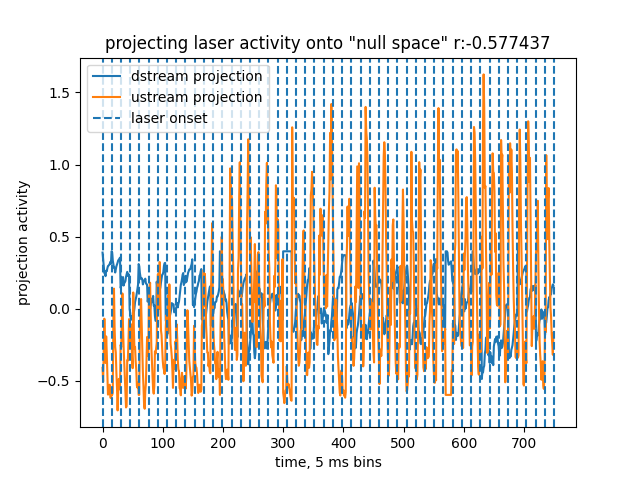

In [90]:
fig, ax = plt.subplots()
ax.plot(null_proj1, label='dstream projection')
ax.plot(null_proj2, label='ustream projection')
ax.legend()
ax.set_ylabel('projection activity')
ax.set_xlabel('time, 5 ms bins')

r=scipy.stats.pearsonr(null_proj1, null_proj2)
ax.set_title(f'projecting laser activity onto "null space" r:{r[0]:1f}')
print(scipy.stats.pearsonr(null_proj1, null_proj2))
for i in np.linspace(0, len(X_laser), num_lasers):
    if i==0:
        ax.axvline(i, linestyle='--', label='laser onset')
    else:
        ax.axvline(i, linestyle='--')
    
ax.legend()

In [290]:
h_PCAobj.components_.shape

(8, 800)

In [158]:
X_ctrl.shape

(870, 800)

In [156]:
null_proj.shape

(870,)

In [154]:
null_proj.shape

(870,)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


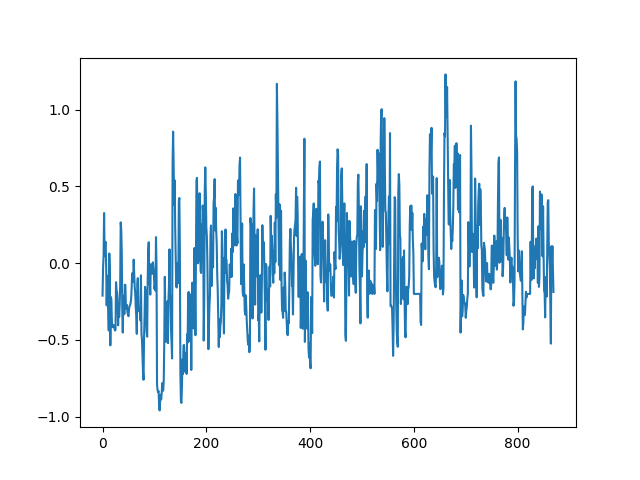

In [153]:
fig, ax = plt.subplots()
ax.plot(null_proj)

In [125]:
yhat1_ctrl = test_wiener_filter(X_ctrl, h1)
yhat2_ctrl = test_wiener_filter(X_ctrl, h2)

yhat1_laser = test_wiener_filter(X_laser, h1)
yhat2_laser = test_wiener_filter(X_laser, h2)
print(weighted_r2(Y_laser, yhat1_laser))
print(weighted_r2(Y_laser, yhat2_laser))


temp1, temp2 = session.relative_input(h1, X_ctrl, nlags, num_region1=num_PCs)
print(np.log10(temp1/temp2))
temp1, temp2 = session.relative_input(h2, X_ctrl, nlags, num_region1=num_PCs)
print(np.log10(temp1/temp2))

0.17969535788654054
0.14489118980539542
0.37371558345932593
5.037590162707523


In [21]:
res1 = (Y_ctrl - yhat1_ctrl)**2
res2 = (Y_ctrl - yhat2_ctrl)**2

In [22]:
res1 = (Y_laser - yhat1_laser)**2
res2 = (Y_laser - yhat2_laser)**2

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


NameError: name 'yhat1_laser' is not defined

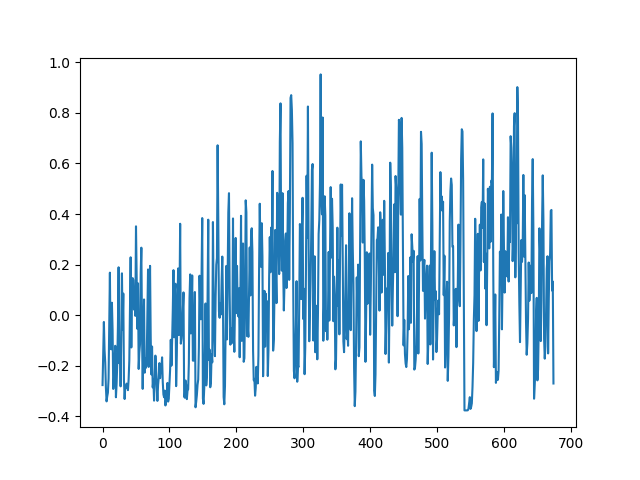

In [19]:
fig, ax = plt.subplots()
ax.plot(Y_laser[:,0])
ax.plot(yhat1_laser[:,0])
ax.plot(yhat2_laser[:,0])

# grave yard

In [30]:
ltop_c_ratio, ltop_c_r2, _ = get_top_models(c_ratio, l_r2, num_bins=20)
ltop_sw_ratio, ltop_sw_r2, _ = get_top_models(sw_ratio, lsw_r2, num_bins=20)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


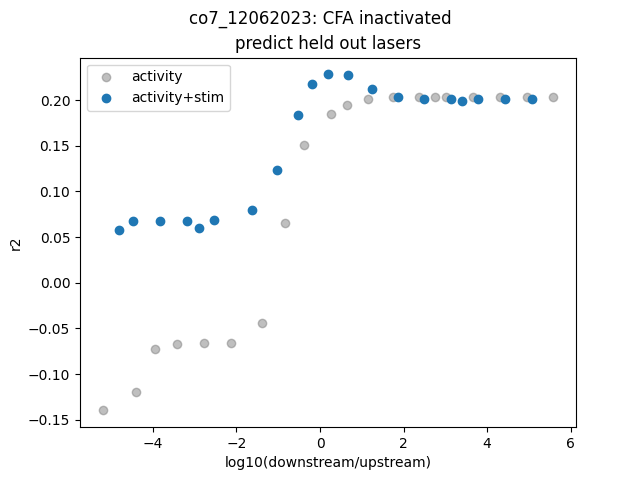

In [31]:
fig, ax = plt.subplots()
ax.scatter(ltop_c_ratio, ltop_c_r2, label='activity', color='gray', alpha=.5)
ax.scatter(ltop_sw_ratio, ltop_sw_r2, label='activity+stim')
#ax.scatter(c_ratio[c_max_idx], l_r2[c_max_idx], color='black')
#ax.scatter(sw_ratio[sw_max_idx], lsw_r2[sw_max_idx], color='blue')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out lasers')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)

In [180]:
sorted_h_sw = [x for _, x in sorted(zip(good_sw_ratio, h_sw_col_list))]
sorted_h = [x for _, x in sorted(zip(good_c_ratio, h_col_list))]

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


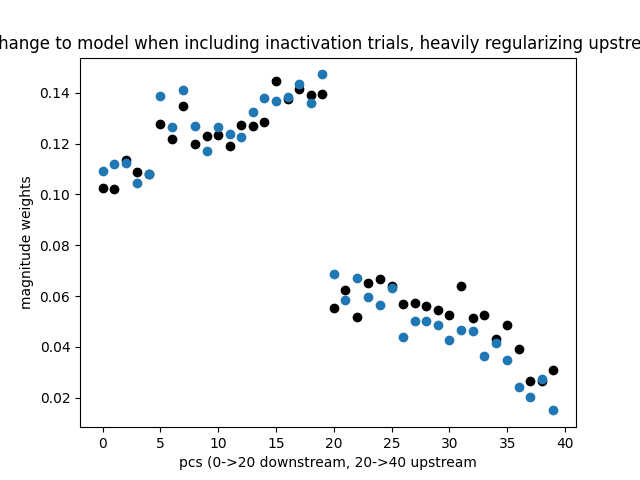

In [186]:
fig, ax = plt.subplots()
ax.set_title('change to model when including inactivation trials, heavily regularizing upstream')
ax.set_ylabel('magnitude weights')
ax.set_xlabel('pcs (0->20 downstream, 20->40 upstream')
ax.scatter(np.arange(len(sorted_h[40])), sorted_h[40], c='black')
ax.scatter(np.arange(len(sorted_h_sw[40])), sorted_h_sw[40])

# how do things change in weight space as you go further right

In [39]:
output = pload('/home/diya/Documents/mp_opto/picklejar/_coSweepRegsSW_20nlag_50post_50sw.pickle')
asymps = pload('/home/diya/Documents/mp_opto/picklejar/_coSweepRegsSWasymps_20nlag_50post_50sw.pickle')

In [42]:
c_r2 = []
c_ratio = []
l_r2=[]
l_ratio=[]

sw_r2 = []
sw_ratio = []
lsw_r2=[]
lsw_ratio=[]

h_list =[]
h_sw_list = []

sesh=0

regs=[]

c_pos_asymps = asymps[sesh][0][0]
c_neg_asymps = asymps[sesh][1][0]

sw_pos_asymps = asymps[sesh][0][1]
sw_neg_asymps = asymps[sesh][1][1]

session_name = output[sesh][0][2][1]
inact = output[sesh][0][2][2]

session_path = f'../data/co/co12/{session_name}'
session = MPOptoClass(session_path)

for run in output[sesh]:
    c=run[0]
    sw=run[1]
    
    regs.append(run[2][0])
    h_list.append(c[0])
   
    d, u = session.weights_per_region(h_list[-1], nlags=20, num_region1=20)
    c_ratio.append(np.log10(d/u))
    
    
    l_r2.append(c[1])
    c_r2.append(c[2])
    
    h_sw_list.append(sw[0])
    
    d, u = session.weights_per_region(h_sw_list[-1], nlags=20, num_region1=20)
    sw_ratio.append(np.log10(d/u))
    #sw_ratio.append(sw[2])
    lsw_r2.append(sw[1])
    sw_r2.append(sw[2])

co12 handfix lol
love


In [49]:
top_ratio, top_r2, idxs, _ = get_top_models(sw_ratio, sw_r2, num_bins=10)

/home/diya/anaconda3/envs/mp_opto/lib/python3.8/site-packages/ipywidgets/widgets/widget.py:501: DeprecationWarning: Passing unrecognized arguments to super(Toolbar).__init__().
__init__() missing 1 required positional argument: 'canvas'
This is deprecated in traitlets 4.2.This error will be raised in a future release of traitlets.
  super().__init__(**kwargs)


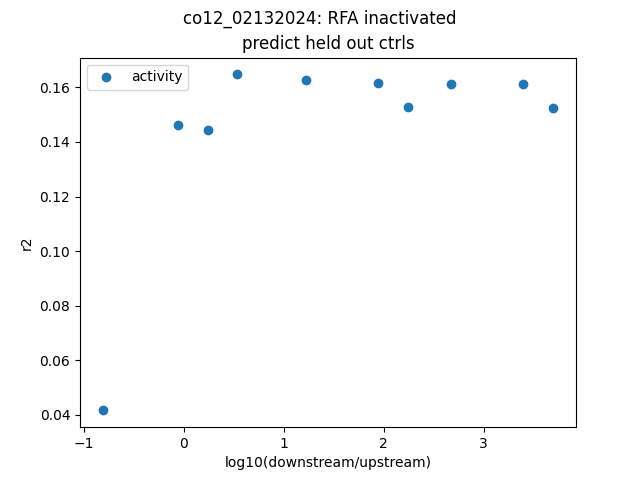

In [48]:
fig, ax = plt.subplots()
ax.scatter(top_ratio, top_r2, label='activity')
#ax.axhline(sw_pos_asymps, xmin=.5, xmax=1, linestyle='--', label='activity asymp', color='gray', alpha=.5)
#ax.scatter(c_ratio[c_max_idx], c_r2[c_max_idx], color='black')
ax.set_ylabel('r2')
ax.set_xlabel('log10(downstream/upstream)')
fig.suptitle(f'{session_name}: {inact} inactivated')
ax.set_title('predict held out ctrls')
#ax.set_ylim(0,.35)
ax.legend()
#ax.set_xlim(-2,2)